In [1]:
import pandas as pd

In [2]:
import numpy as np

In [4]:
df = pd.read_csv(r'nifty_daily.csv.csv')

In [62]:
print(df.shape)
df.head()

(2724, 6)


,Index Name,Date,Open,High,Low,Close
0,NIFTY 50,20 Sep 2024,25525.95,25849.25,25426.60,25790.95
1,NIFTY 50,19 Sep 2024,25487.05,25611.95,25376.05,25415.80
2,NIFTY 50,18 Sep 2024,25402.40,25482.20,25285.55,25377.55
3,NIFTY 50,17 Sep 2024,25416.90,25441.65,25352.25,25418.55
4,NIFTY 50,16 Sep 2024,25406.65,25445.70,25336.20,25383.75


In [63]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [64]:
df

,Index Name,Date,Open,High,Low,Close
0,NIFTY 50,2024-09-20,25525.95,25849.25,25426.60,25790.95
1,NIFTY 50,2024-09-19,25487.05,25611.95,25376.05,25415.80
2,NIFTY 50,2024-09-18,25402.40,25482.20,25285.55,25377.55
3,NIFTY 50,2024-09-17,25416.90,25441.65,25352.25,25418.55
4,NIFTY 50,2024-09-16,25406.65,25445.70,25336.20,25383.75
...,...,...,...,...,...,...
2719,NIFTY 50,2022-09-28,16870.55,17037.60,16820.40,16858.60
2720,NIFTY 50,2022-09-27,17110.90,17176.45,16942.35,17007.40
2721,NIFTY 50,2022-09-26,17156.30,17196.40,16978.30,17016.30
2722,NIFTY 50,2022-09-23,17593.85,17642.15,17291.65,17327.35


In [65]:
df["Date"].isna().sum()

0

In [66]:
df = df.sort_values("Date").reset_index(drop=True)

In [67]:
df

,Index Name,Date,Open,High,Low,Close
0,NIFTY 50,2015-09-22,8014.80,8021.60,7787.75,7812.00
1,NIFTY 50,2015-09-23,7737.35,7882.90,7723.25,7845.95
2,NIFTY 50,2015-09-24,7838.40,7894.50,7804.10,7868.50
3,NIFTY 50,2015-09-28,7892.80,7893.95,7787.95,7795.70
4,NIFTY 50,2015-09-29,7725.70,7926.55,7691.20,7843.30
...,...,...,...,...,...,...
2719,NIFTY 50,2026-09-11,23270.30,23448.10,23231.40,23398.10
2720,NIFTY 50,2026-09-15,23576.15,23592.85,23118.60,23118.60
2721,NIFTY 50,2026-09-16,23201.60,23284.75,23116.10,23217.60
2722,NIFTY 50,2026-09-17,23195.25,23363.55,23193.65,23270.60


In [120]:
df["Date"].duplicated().sum()

0

In [121]:
df = df.drop_duplicates(subset=["Date"], keep="first").reset_index(drop=True)

In [122]:
df[["Date", "Open", "High", "Low", "Close"]].isna().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

In [123]:
df[["Open", "High", "Low", "Close"]].dtypes

Open     float64
High     float64
Low      float64
Close    float64
dtype: object

In [124]:
(df[["Open", "High", "Low", "Close"]] <= 0).sum()

Open     0
High     0
Low      0
Close    0
dtype: int64

In [125]:
invalid_ohlc = (
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"]) |
    (df["Low"] > df["Open"]) |
    (df["Low"] > df["Close"])
)

print("Invalid OHLC rows:", invalid_ohlc.sum())

Invalid OHLC rows: 0


In [126]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Total rows:", len(df))

Start date: 2015-09-22 00:00:00
End date: 2026-09-18 00:00:00
Total rows: 2722


In [75]:
print(df.shape)
print(df.columns)
print(df["Date"].min())
print(df["Date"].max())
print(df["Date"].duplicated().sum())
print(df[["Date","Open","High","Low","Close"]].isna().sum())
print(invalid_ohlc.sum())

(2722, 6)
Index(['Index Name', 'Date', 'Open', 'High', 'Low', 'Close'], dtype='object')
2015-09-22 00:00:00
2026-09-18 00:00:00
0
Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64
0


In [76]:
df["Daily_Return"] = df["Close"].pct_change() * 100

print(df["Daily_Return"].describe())

count    2721.000000
mean        0.045378
std         1.009932
min       -12.980464
25%        -0.423634
50%         0.062469
75%         0.570498
max         8.763205
Name: Daily_Return, dtype: float64


In [77]:
df.nsmallest(10, "Daily_Return")[[
    "Date", "Open", "High", "Low", "Close", "Daily_Return"
]]

,Date,Open,High,Low,Close,Daily_Return
1110,2020-03-23,7945.70,8159.25,7583.60,7610.25,-12.980464
1103,2020-03-12,10039.95,10040.75,9508.00,9590.15,-8.301939
1105,2020-03-16,9587.80,9602.20,9165.10,9197.40,-7.612102
2152,2024-06-04,23179.50,23179.50,21281.45,21884.50,-5.929358
1135,2020-05-04,9533.50,9533.50,9266.95,9293.50,-5.744480
1107,2020-03-18,9088.45,9127.55,8407.05,8468.80,-5.556454
1101,2020-03-09,10742.05,10751.55,10294.45,10451.45,-4.895604
1590,2022-02-24,16548.90,16705.25,16203.25,16247.95,-4.778105
1115,2020-03-30,8385.95,8576.00,8244.00,8281.10,-4.378049
1117,2020-04-01,8584.10,8588.10,8198.35,8253.80,-4.000465


In [78]:
df.nlargest(10, "Daily_Return")[[
    "Date", "Open", "High", "Low", "Close", "Daily_Return"
]]

,Date,Open,High,Low,Close,Daily_Return
1119,2020-04-07,8446.30,8819.40,8360.95,8792.20,8.763205
1112,2020-03-25,7735.15,8376.75,7714.75,8317.85,6.624749
1109,2020-03-20,8284.45,8883.00,8178.20,8745.45,5.832915
985,2019-09-20,10746.80,11381.90,10691.00,11274.20,5.319109
1325,2021-02-01,13758.60,14336.35,13661.75,14281.20,4.742347
1121,2020-04-09,8973.05,9128.35,8904.55,9111.90,4.150879
1113,2020-03-26,8451.00,8749.05,8304.90,8641.45,3.890428
1116,2020-03-31,8529.35,8678.30,8358.00,8597.75,3.823767
2383,2025-05-12,24420.10,24944.80,24378.85,24924.70,3.818311
1104,2020-03-13,9107.60,10159.40,8555.15,9955.20,3.806510


In [79]:
df.loc[df["Date"] == "2020-03-23",
       ["Date", "Open", "High", "Low", "Close", "Daily_Return"]]

,Date,Open,High,Low,Close,Daily_Return
1110,2020-03-23,7945.7,8159.25,7583.6,7610.25,-12.980464


In [81]:
df.loc[df["Date"].isin(["2020-03-23", "2020-03-24"]),
       ["Date", "Open", "High", "Low", "Close", "Daily_Return"]]

,Date,Open,High,Low,Close,Daily_Return
1110,2020-03-23,7945.7,8159.25,7583.6,7610.25,-12.980464
1111,2020-03-24,7848.3,8036.95,7511.1,7801.05,2.507145


In [82]:
df.loc[1109:1119, 
       ["Date", "Open", "High", "Low", "Close", "Daily_Return"]]

,Date,Open,High,Low,Close,Daily_Return
1109,2020-03-20,8284.45,8883.00,8178.20,8745.45,5.832915
1110,2020-03-23,7945.70,8159.25,7583.60,7610.25,-12.980464
1111,2020-03-24,7848.30,8036.95,7511.10,7801.05,2.507145
1112,2020-03-25,7735.15,8376.75,7714.75,8317.85,6.624749
1113,2020-03-26,8451.00,8749.05,8304.90,8641.45,3.890428
1114,2020-03-27,8949.10,9038.90,8522.90,8660.25,0.217556
1115,2020-03-30,8385.95,8576.00,8244.00,8281.10,-4.378049
1116,2020-03-31,8529.35,8678.30,8358.00,8597.75,3.823767
1117,2020-04-01,8584.10,8588.10,8198.35,8253.80,-4.000465
1118,2020-04-03,8356.55,8356.55,8055.80,8083.80,-2.059657


In [127]:
EVENT_THRESHOLD = -2.0

events = df[df["Daily_Return"] <= EVENT_THRESHOLD].copy()

print("Number of significant fall events:", len(events))

events[[
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Daily_Return"
]]

Number of significant fall events: 62


,Date,Open,High,Low,Close,Daily_Return
68,2016-01-04,7924.55,7937.55,7781.10,7791.30,-2.158680
71,2016-01-07,7673.35,7674.95,7556.60,7568.30,-2.230978
95,2016-02-11,7203.60,7208.65,6959.95,6976.35,-3.317072
130,2016-04-05,7736.30,7736.30,7588.65,7603.20,-2.005465
185,2016-06-24,8029.10,8100.70,7927.05,8088.60,-2.198792
...,...,...,...,...,...,...
2598,2026-03-19,23197.75,23378.70,22930.35,23002.15,-3.262076
2600,2026-03-23,22824.35,22851.70,22471.25,22512.65,-2.603777
2603,2026-03-27,23173.55,23186.10,22804.55,22819.60,-2.088907
2604,2026-03-30,22549.65,22714.10,22283.85,22331.40,-2.139389


In [128]:
HOLDING_PERIODS = [1, 3, 5]

results = []

for i in events.index:
    entry = i + 1

    if entry + 4 >= len(df):
        continue

    data = {
        "Event_Date": df.loc[i, "Date"],
        "Event_Return": df.loc[i, "Daily_Return"],
        "Entry_Date": df.loc[entry, "Date"],
        "Entry_Price": df.loc[entry, "Open"]
    }

    for days in HOLDING_PERIODS:
        exit_price = df.loc[entry + days - 1, "Close"]
        data[f"Return_{days}D"] = (
            exit_price / data["Entry_Price"] - 1
        ) * 100

    results.append(data)

results = pd.DataFrame(results)

results

,Event_Date,Event_Return,Entry_Date,Entry_Price,Return_1D,Return_3D,Return_5D
0,2016-01-04,-2.158680,2016-01-05,7828.40,-0.558863,-3.322518,-3.379362
1,2016-01-07,-2.230978,2016-01-08,7611.65,-0.135319,-1.331512,-0.983361
2,2016-02-11,-3.317072,2016-02-12,7023.65,-0.607946,0.350245,2.393342
3,2016-04-05,-2.005465,2016-04-06,7636.05,-0.284178,-1.058793,0.954682
4,2016-06-24,-2.198792,2016-06-27,8039.35,0.688488,2.048051,3.594818
...,...,...,...,...,...,...,...
57,2026-03-19,-3.262076,2026-03-20,23110.15,0.018823,-0.855685,-1.257240
58,2026-03-23,-2.603777,2026-03-24,22878.45,0.148393,-0.257229,-0.870033
59,2026-03-27,-2.088907,2026-03-30,22549.65,-0.967864,0.724845,2.545494
60,2026-03-30,-2.139389,2026-04-01,22899.00,-0.958994,0.302415,4.796498


In [129]:
events_sorted = events.sort_index()

for i in range(len(events_sorted) - 1):
    current = events_sorted.index[i]
    next_event = events_sorted.index[i + 1]

    gap = next_event - current

    print(
        df.loc[current, "Date"].date(),
        "→",
        df.loc[next_event, "Date"].date(),
        "| Trading days gap:",
        gap
    )

2016-01-04 → 2016-01-07 | Trading days gap: 3
2016-01-07 → 2016-02-11 | Trading days gap: 24
2016-02-11 → 2016-04-05 | Trading days gap: 35
2016-04-05 → 2016-06-24 | Trading days gap: 55
2016-06-24 → 2016-11-11 | Trading days gap: 94
2016-11-11 → 2016-11-15 | Trading days gap: 1
2016-11-15 → 2018-02-02 | Trading days gap: 305
2018-02-02 → 2018-10-04 | Trading days gap: 164
2018-10-04 → 2018-10-05 | Trading days gap: 1
2018-10-05 → 2018-10-11 | Trading days gap: 4
2018-10-11 → 2019-07-08 | Trading days gap: 181
2019-07-08 → 2019-09-03 | Trading days gap: 38
2019-09-03 → 2020-02-01 | Trading days gap: 103
2020-02-01 → 2020-02-24 | Trading days gap: 15
2020-02-24 → 2020-02-28 | Trading days gap: 4
2020-02-28 → 2020-03-06 | Trading days gap: 5
2020-03-06 → 2020-03-09 | Trading days gap: 1
2020-03-09 → 2020-03-12 | Trading days gap: 2
2020-03-12 → 2020-03-16 | Trading days gap: 2
2020-03-16 → 2020-03-17 | Trading days gap: 1
2020-03-17 → 2020-03-18 | Trading days gap: 1
2020-03-18 → 2020-03

In [130]:
def remove_overlapping_events(events, holding_days):
    selected = []
    last_event = -999

    for i in events.index:
        if i - last_event > holding_days:
            selected.append(i)
            last_event = i

    return events.loc[selected]

In [131]:
events_5d = remove_overlapping_events(events, 5)

print("Original events:", len(events))
print("Non-overlapping 5D events:", len(events_5d))

events_5d[["Date", "Daily_Return"]]

Original events: 62
Non-overlapping 5D events: 41


,Date,Daily_Return
68,2016-01-04,-2.158680
95,2016-02-11,-3.317072
130,2016-04-05,-2.005465
185,2016-06-24,-2.198792
279,2016-11-11,-2.691259
585,2018-02-02,-2.326426
749,2018-10-04,-2.385283
935,2019-07-08,-2.138234
973,2019-09-03,-2.044315
1076,2020-02-01,-2.510011


In [132]:
results_5d = results[
    results["Event_Date"].isin(events_5d["Date"])
].copy()

results_5d

,Event_Date,Event_Return,Entry_Date,Entry_Price,Return_1D,Return_3D,Return_5D
0,2016-01-04,-2.158680,2016-01-05,7828.40,-0.558863,-3.322518,-3.379362
2,2016-02-11,-3.317072,2016-02-12,7023.65,-0.607946,0.350245,2.393342
3,2016-04-05,-2.005465,2016-04-06,7636.05,-0.284178,-1.058793,0.954682
4,2016-06-24,-2.198792,2016-06-27,8039.35,0.688488,2.048051,3.594818
5,2016-11-11,-2.691259,2016-11-15,8284.85,-2.129188,-2.473189,-4.293982
7,2018-02-02,-2.326426,2018-02-05,10604.30,0.587026,-1.203285,-1.408391
8,2018-10-04,-2.385283,2018-10-05,10514.10,-1.879857,-2.026327,-2.657859
11,2019-07-08,-2.138234,2019-07-09,11531.60,0.210725,0.444865,0.492126
12,2019-09-03,-2.044315,2019-09-04,10790.40,0.502762,1.443876,2.273317
13,2020-02-01,-2.510011,2020-02-03,11627.45,0.691897,3.970776,4.049899


In [133]:
for col in ["Return_1D", "Return_3D", "Return_5D"]:
    print("\n", col)
    print("Mean:", results_5d[col].mean())
    print("Median:", results_5d[col].median())
    print("Win Rate:", (results_5d[col] > 0).mean() * 100)
    print("Std Dev:", results_5d[col].std())


 Return_1D
Mean: -0.02187879572630553
Median: 0.14839291997490456
Win Rate: 56.09756097560976
Std Dev: 1.7383306160235206

 Return_3D
Mean: -0.03978078229730646
Median: 0.5508404350898166
Win Rate: 58.536585365853654
Std Dev: 3.0618159175025057

 Return_5D
Mean: -0.11290474048128768
Median: 0.18562449215939747
Win Rate: 51.21951219512195
Std Dev: 4.32726815352331


In [134]:
baseline = df.copy()

# Event days ko remove karo
baseline = baseline[~baseline["Date"].isin(events["Date"])].copy()

for days in [1, 3, 5]:
    baseline[f"Return_{days}D"] = (
        baseline["Close"].shift(-days) / baseline["Close"] - 1
    ) * 100

baseline = baseline.dropna()

for days in [1, 3, 5]:
    col = f"Return_{days}D"
    
    print("\n", col)
    print("Mean:", baseline[col].mean())
    print("Median:", baseline[col].median())
    print("Win Rate:", (baseline[col] > 0).mean() * 100)
    print("Std Dev:", baseline[col].std())


 Return_1D
Mean: 0.0457275298701646
Median: 0.05782283779676156
Win Rate: 53.65486058779201
Std Dev: 0.9490893008581829

 Return_3D
Mean: 0.138598741820326
Median: 0.20836563292265797
Win Rate: 56.21703089675961
Std Dev: 1.7404228128033485

 Return_5D
Mean: 0.23127699437967605
Median: 0.36970240499228924
Win Rate: 57.68651092690279
Std Dev: 2.2627465994322837


In [92]:
baseline = []

for i in df.index:

    # Event day ko baseline se hatao
    if df.loc[i, "Date"] in events["Date"].values:
        continue

    # Next day available hai ya nahi?
    if i + 5 >= len(df):
        continue

    entry_price = df.loc[i + 1, "Open"]

    row = {
        "Date": df.loc[i, "Date"],
        "Entry_Price": entry_price
    }

    for days in [1, 3, 5]:
        exit_price = df.loc[i + days, "Close"]

        row[f"Return_{days}D"] = (
            exit_price / entry_price - 1
        ) * 100

    baseline.append(row)

baseline = pd.DataFrame(baseline)

baseline.head()

,Date,Entry_Price,Return_1D,Return_3D,Return_5D
0,2015-09-22,7737.35,1.403581,0.754134,2.734140
1,2015-09-23,7838.40,0.384007,0.062513,1.435242
2,2015-09-24,7892.80,-1.230235,0.710774,2.869704
3,2015-09-28,7725.70,1.522192,2.914946,5.529596
4,2015-09-29,7924.25,0.311070,2.461432,3.194624


In [50]:
for col in ["Return_1D", "Return_3D", "Return_5D"]:
    print("\n", col)
    print("Mean:", baseline[col].mean())
    print("Median:", baseline[col].median())
    print("Win Rate:", (baseline[col] > 0).mean() * 100)
    print("Std Dev:", baseline[col].std())


 Return_1D
Mean: -0.03232347023647103
Median: -0.0369784481907387
Win Rate: 46.83195592286501
Std Dev: 0.6556459069812208

 Return_3D
Mean: 0.005907785175012652
Median: -0.006081816745312496
Win Rate: 49.72451790633609
Std Dev: 1.2956249173236152

 Return_5D
Mean: 0.05337614827745202
Median: -0.0017798571379623596
Win Rate: 50.0
Std Dev: 1.7219160287196569


In [93]:
for days in [1, 3, 5]:
    
    col = f"Return_{days}D"
    
    event_mean = results_5d[col].mean()
    baseline_mean = baseline[col].mean()
    
    event_win = (results_5d[col] > 0).mean() * 100
    baseline_win = (baseline[col] > 0).mean() * 100
    
    print(f"\n{days}D")
    print("Event Mean:", event_mean)
    print("Baseline Mean:", baseline_mean)
    print("Mean Difference:", event_mean - baseline_mean)
    
    print("Event Win Rate:", event_win)
    print("Baseline Win Rate:", baseline_win)
    print("Win Rate Difference:", event_win - baseline_win)


1D
Event Mean: -0.02187879572630553
Baseline Mean: -0.0694500940705517
Mean Difference: 0.047571298344246164
Event Win Rate: 56.09756097560976
Baseline Win Rate: 46.365348399246706
Win Rate Difference: 9.732212576363054

3D
Event Mean: -0.03978078229730646
Baseline Mean: 0.02469777732942032
Mean Difference: -0.06447855962672677
Event Win Rate: 58.536585365853654
Baseline Win Rate: 52.95668549905837
Win Rate Difference: 5.57989986679528

5D
Event Mean: -0.11290474048128768
Baseline Mean: 0.12280692998352459
Mean Difference: -0.23571167046481228
Event Win Rate: 51.21951219512195
Baseline Win Rate: 54.08662900188324
Win Rate Difference: -2.867116806761288


In [51]:
import numpy as np

def bootstrap_ci(data, n=10000):
    means = []

    for _ in range(n):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(sample.mean())

    return np.percentile(means, [2.5, 97.5])


for col in ["Return_1D", "Return_3D", "Return_5D"]:
    ci = bootstrap_ci(results_5d[col].dropna().values)

    print(col)
    print("Mean:", results_5d[col].mean())
    print("95% CI:", ci)
    print()

Return_1D
Mean: 0.3650985508075591
95% CI: [-0.24398699  1.0052416 ]

Return_3D
Mean: 1.3124806835107208
95% CI: [0.15739318 2.69115953]

Return_5D
Mean: 1.1753983605663363
95% CI: [-0.16000672  2.7496391 ]



In [52]:
comparison = pd.DataFrame({
    "Holding": ["1 Day", "3 Days", "5 Days"],
    "Event_Mean": [
        results_5d["Return_1D"].mean(),
        results_5d["Return_3D"].mean(),
        results_5d["Return_5D"].mean()
    ],
    "Baseline_Mean": [
        baseline["Return_1D"].mean(),
        baseline["Return_3D"].mean(),
        baseline["Return_5D"].mean()
    ]
})

comparison["Difference"] = (
    comparison["Event_Mean"] - comparison["Baseline_Mean"]
)

comparison

,Holding,Event_Mean,Baseline_Mean,Difference
0,1 Day,0.365099,-0.032323,0.397422
1,3 Days,1.312481,0.005908,1.306573
2,5 Days,1.175398,0.053376,1.122022


In [53]:
thresholds = [-1.5, -2.0, -2.5, -3.0]

robustness = []

for threshold in thresholds:

    e = df[df["Daily_Return"] <= threshold].copy()
    
    # 5-day non-overlapping events
    e = remove_overlapping_events(e, 5)

    r = results[results["Event_Date"].isin(e["Date"])]

    robustness.append({
        "Threshold": threshold,
        "Events": len(r),
        "Mean_1D": r["Return_1D"].mean(),
        "Mean_3D": r["Return_3D"].mean(),
        "Mean_5D": r["Return_5D"].mean()
    })

robustness = pd.DataFrame(robustness)

robustness

,Threshold,Events,Mean_1D,Mean_3D,Mean_5D
0,-1.5,7,0.360550,1.256990,0.712963
1,-2.0,8,0.365099,1.312481,1.175398
2,-2.5,4,0.455881,1.448587,2.235200
3,-3.0,3,0.879718,2.031836,2.763716


In [95]:
import numpy as np

for days in [1, 3, 5]:
    col = f"Return_{days}D"
    
    baseline_mean = baseline[col].mean()
    
    results_5d[f"AR_{days}D"] = (
        results_5d[col] - baseline_mean
    )

In [96]:
results_5d["CAR_1D"] = results_5d["AR_1D"]

results_5d["CAR_3D"] = (
    results_5d["AR_1D"] +
    results_5d["AR_3D"]
)

results_5d["CAR_5D"] = (
    results_5d["AR_1D"] +
    results_5d["AR_3D"] +
    results_5d["AR_5D"]
)

In [99]:
results_5d[
    [
        "Event_Date",
        "Return_1D",
        "Return_3D",
        "Return_5D",
        "AR_1D",
        "AR_3D",
        "AR_5D",
        "CAR_1D",
        "CAR_3D",
        "CAR_5D"
    ]
].head()

,Event_Date,Return_1D,Return_3D,Return_5D,AR_1D,AR_3D,AR_5D,CAR_1D,CAR_3D,CAR_5D
0,2016-01-04,-0.558863,-3.322518,-3.379362,-0.489413,-3.347216,-3.502169,-0.489413,-3.836628,-7.338798
2,2016-02-11,-0.607946,0.350245,2.393342,-0.538496,0.325547,2.270536,-0.538496,-0.212948,2.057587
3,2016-04-05,-0.284178,-1.058793,0.954682,-0.214728,-1.083491,0.831875,-0.214728,-1.298220,-0.466344
4,2016-06-24,0.688488,2.048051,3.594818,0.757939,2.023353,3.472011,0.757939,2.781292,6.253303
5,2016-11-11,-2.129188,-2.473189,-4.293982,-2.059738,-2.497887,-4.416789,-2.059738,-4.557624,-8.974414


In [100]:
from scipy import stats
import numpy as np

for days in [1, 3, 5]:
    
    col = f"Return_{days}D"
    
    data = results_5d[col].dropna()
    
    mean = data.mean()
    n = len(data)
    std = data.std(ddof=1)
    
    se = std / np.sqrt(n)
    
    ci_low, ci_high = stats.t.interval(
        0.95,
        df=n-1,
        loc=mean,
        scale=se
    )
    
    print(f"\n{days}D")
    print("Observations:", n)
    print("Mean Return:", mean)
    print("95% CI:", ci_low, "to", ci_high)


1D
Observations: 41
Mean Return: -0.02187879572630553
95% CI: -0.5705636385118665 to 0.5268060470592554

3D
Observations: 41
Mean Return: -0.03978078229730646
95% CI: -1.006209130189017 to 0.9266475655944042

5D
Observations: 41
Mean Return: -0.11290474048128768
95% CI: -1.4787590978866667 to 1.2529496169240912


In [102]:
from scipy.stats import ttest_ind

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    event = results_5d[col].dropna()
    base = baseline[col].dropna()

    # Welch's t-test
    t_stat, p_two = ttest_ind(
        event,
        base,
        equal_var=False
    )

    # One-sided p-value
    if t_stat > 0:
        p_one = p_two / 2
    else:
        p_one = 1 - (p_two / 2)

    print(f"\n{days}D")
    print("Event Mean:", event.mean())
    print("Baseline Mean:", base.mean())
    print("Mean Difference:", event.mean() - base.mean())
    print("t-statistic:", t_stat)
    print("One-sided p-value:", p_one)


1D
Event Mean: -0.02187879572630553
Baseline Mean: -0.0694500940705517
Mean Difference: 0.047571298344246164
t-statistic: 0.17496989367635699
One-sided p-value: 0.43099039315615884

3D
Event Mean: -0.03978078229730646
Baseline Mean: 0.02469777732942032
Mean Difference: -0.06447855962672677
t-statistic: -0.13459137479705163
One-sided p-value: 0.5531975387296185

5D
Event Mean: -0.11290474048128768
Baseline Mean: 0.12280692998352459
Mean Difference: -0.23571167046481228
t-statistic: -0.34819812753626433
One-sided p-value: 0.6352474585112386


In [103]:
import numpy as np

rng = np.random.default_rng(42)

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    event = results_5d[col].dropna().to_numpy()
    base = baseline[col].dropna().to_numpy()

    bootstrap_diffs = []

    for _ in range(10000):

        event_sample = rng.choice(
            event,
            size=len(event),
            replace=True
        )

        base_sample = rng.choice(
            base,
            size=len(base),
            replace=True
        )

        diff = event_sample.mean() - base_sample.mean()

        bootstrap_diffs.append(diff)

    bootstrap_diffs = np.array(bootstrap_diffs)

    ci_low = np.percentile(bootstrap_diffs, 2.5)
    ci_high = np.percentile(bootstrap_diffs, 97.5)

    observed_diff = event.mean() - base.mean()

    print(f"\n{days}D")
    print("Observed Mean Difference:", observed_diff)
    print("Bootstrap 95% CI:", ci_low, "to", ci_high)


1D
Observed Mean Difference: 0.047571298344246164
Bootstrap 95% CI: -0.5114555717260698 to 0.5605845539758372

3D
Observed Mean Difference: -0.06447855962672677
Bootstrap 95% CI: -1.0158962743943134 to 0.820787864456127

5D
Observed Mean Difference: -0.23571167046481228
Bootstrap 95% CI: -1.6370969024792175 to 1.0046397034526473


In [104]:
print("Current event threshold:")
print(threshold)

Current event threshold:
-3.0


In [107]:
thresholds = [-2.0, -2.5, -3.0, -3.5, -4.0]

robustness_results = []

for threshold in thresholds:

    event_rows = []

    # Events identify karo
    for i in df.index:

        if df.loc[i, "Daily_Return"] > threshold:
            continue

        # Next 5 trading days available hone chahiye
        if i + 5 >= len(df):
            continue

        entry_price = df.loc[i + 1, "Open"]

        row = {
            "Event_Date": df.loc[i, "Date"],
            "Event_Return": df.loc[i, "Daily_Return"],
            "Entry_Price": entry_price
        }

        # 1D, 3D, 5D forward returns
        for days in [1, 3, 5]:

            exit_price = df.loc[i + days, "Close"]

            row[f"Return_{days}D"] = (
                exit_price / entry_price - 1
            ) * 100

        event_rows.append(row)

    temp = pd.DataFrame(event_rows)

    if len(temp) == 0:
        continue

    robustness_results.append({
        "Threshold": threshold,
        "Events": len(temp),

        "Mean_1D": temp["Return_1D"].mean(),
        "Mean_3D": temp["Return_3D"].mean(),
        "Mean_5D": temp["Return_5D"].mean(),

        "Win_1D": (temp["Return_1D"] > 0).mean() * 100,
        "Win_3D": (temp["Return_3D"] > 0).mean() * 100,
        "Win_5D": (temp["Return_5D"] > 0).mean() * 100
    })

robustness = pd.DataFrame(robustness_results)

print(robustness)

   Threshold  Events   Mean_1D   Mean_3D   Mean_5D     Win_1D     Win_3D  \
0       -2.0      63  0.229402  0.081702 -0.096504  57.142857  58.730159   
1       -2.5      33  0.217832  0.098584 -0.306546  63.636364  57.575758   
2       -3.0      21  0.551800  0.253771 -0.181153  66.666667  61.904762   
3       -3.5      14  0.553906 -0.278208 -1.415835  64.285714  50.000000   
4       -4.0      11  0.783179 -0.741123 -1.586642  63.636364  45.454545   

      Win_5D  
0  55.555556  
1  60.606061  
2  61.904762  
3  50.000000  
4  54.545455  


In [106]:
print(df.columns.tolist())

['Index Name', 'Date', 'Open', 'High', 'Low', 'Close', 'Daily_Return']


In [108]:
for threshold in thresholds:

    event_data = []

    for i in df.index:

        if df.loc[i, "Daily_Return"] > threshold:
            continue

        if i + 5 >= len(df):
            continue

        entry_price = df.loc[i + 1, "Open"]

        row = {}

        for days in [1, 3, 5]:

            exit_price = df.loc[i + days, "Close"]

            row[f"Return_{days}D"] = (
                exit_price / entry_price - 1
            ) * 100

        event_data.append(row)

    temp = pd.DataFrame(event_data)

    print(f"\nThreshold: {threshold}%")

    for days in [1, 3, 5]:

        col = f"Return_{days}D"

        event_mean = temp[col].mean()
        baseline_mean = baseline[col].mean()

        difference = event_mean - baseline_mean

        print(
            f"{days}D | "
            f"Event: {event_mean:.3f}% | "
            f"Baseline: {baseline_mean:.3f}% | "
            f"Difference: {difference:.3f}%"
        )


Threshold: -2.0%
1D | Event: 0.229% | Baseline: -0.069% | Difference: 0.299%
3D | Event: 0.082% | Baseline: 0.025% | Difference: 0.057%
5D | Event: -0.097% | Baseline: 0.123% | Difference: -0.219%

Threshold: -2.5%
1D | Event: 0.218% | Baseline: -0.069% | Difference: 0.287%
3D | Event: 0.099% | Baseline: 0.025% | Difference: 0.074%
5D | Event: -0.307% | Baseline: 0.123% | Difference: -0.429%

Threshold: -3.0%
1D | Event: 0.552% | Baseline: -0.069% | Difference: 0.621%
3D | Event: 0.254% | Baseline: 0.025% | Difference: 0.229%
5D | Event: -0.181% | Baseline: 0.123% | Difference: -0.304%

Threshold: -3.5%
1D | Event: 0.554% | Baseline: -0.069% | Difference: 0.623%
3D | Event: -0.278% | Baseline: 0.025% | Difference: -0.303%
5D | Event: -1.416% | Baseline: 0.123% | Difference: -1.539%

Threshold: -4.0%
1D | Event: 0.783% | Baseline: -0.069% | Difference: 0.853%
3D | Event: -0.741% | Baseline: 0.025% | Difference: -0.766%
5D | Event: -1.587% | Baseline: 0.123% | Difference: -1.709%


In [109]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

split_index = int(len(df) * 0.80)

print("\nSplit Date:", df.iloc[split_index]["Date"])


Start Date: 2015-09-22 00:00:00
End Date: 2026-09-18 00:00:00

Split Date: 2024-07-10 00:00:00


In [110]:
split_date = df.iloc[split_index]["Date"]

# OOS data
oos_df = df[df["Date"] >= split_date].copy().reset_index(drop=True)

oos_events = []

threshold = -3.0

for i in oos_df.index:

    # Significant fall
    if oos_df.loc[i, "Daily_Return"] > threshold:
        continue

    # Next 5 trading days available hone chahiye
    if i + 5 >= len(oos_df):
        continue

    entry_price = oos_df.loc[i + 1, "Open"]

    row = {
        "Event_Date": oos_df.loc[i, "Date"],
        "Event_Return": oos_df.loc[i, "Daily_Return"],
        "Entry_Price": entry_price
    }

    for days in [1, 3, 5]:

        exit_price = oos_df.loc[i + days, "Close"]

        row[f"Return_{days}D"] = (
            exit_price / entry_price - 1
        ) * 100

    oos_events.append(row)

oos_results = pd.DataFrame(oos_events)

print("OOS Events:", len(oos_results))

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    print(f"\n{days}D")
    print("Mean:", oos_results[col].mean())
    print("Median:", oos_results[col].median())
    print("Win Rate:", (oos_results[col] > 0).mean() * 100)

OOS Events: 2

1D
Mean: 0.2078811607328035
Median: 0.2078811607328035
Win Rate: 100.0

3D
Mean: 0.4226148814233388
Median: 0.4226148814233388
Win Rate: 50.0

5D
Mean: 1.5776014984991482
Median: 1.5776014984991482
Win Rate: 50.0


In [111]:
# Development data
dev_df = df[df["Date"] < split_date].copy().reset_index(drop=True)

threshold = -3.0

dev_events = []

for i in dev_df.index:

    if dev_df.loc[i, "Daily_Return"] > threshold:
        continue

    if i + 5 >= len(dev_df):
        continue

    entry_price = dev_df.loc[i + 1, "Open"]

    row = {
        "Event_Date": dev_df.loc[i, "Date"],
        "Event_Return": dev_df.loc[i, "Daily_Return"],
        "Entry_Price": entry_price
    }

    for days in [1, 3, 5]:

        exit_price = dev_df.loc[i + days, "Close"]

        row[f"Return_{days}D"] = (
            exit_price / entry_price - 1
        ) * 100

    dev_events.append(row)

dev_results = pd.DataFrame(dev_events)


print("DEVELOPMENT PERIOD")
print("------------------")
print("Events:", len(dev_results))

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    print(
        f"{days}D | "
        f"Mean: {dev_results[col].mean():.3f}% | "
        f"Win Rate: {(dev_results[col] > 0).mean() * 100:.1f}%"
    )


print("\nOOS PERIOD")
print("----------")
print("Events:", len(oos_results))

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    print(
        f"{days}D | "
        f"Mean: {oos_results[col].mean():.3f}% | "
        f"Win Rate: {(oos_results[col] > 0).mean() * 100:.1f}%"
    )

DEVELOPMENT PERIOD
------------------
Events: 19
1D | Mean: 0.588% | Win Rate: 63.2%
3D | Mean: 0.236% | Win Rate: 63.2%
5D | Mean: -0.366% | Win Rate: 63.2%

OOS PERIOD
----------
Events: 2
1D | Mean: 0.208% | Win Rate: 100.0%
3D | Mean: 0.423% | Win Rate: 50.0%
5D | Mean: 1.578% | Win Rate: 50.0%


In [112]:
event_dates = pd.to_datetime(results_5d["Event_Date"]).sort_values().reset_index(drop=True)

gaps = event_dates.diff().dt.days.dropna()

print("Number of events:", len(event_dates))

print("\nGap between events:")
print(gaps.describe())

print("\nEvents occurring within:")
print("1 day :", (gaps <= 1).sum())
print("3 days:", (gaps <= 3).sum())
print("5 days:", (gaps <= 5).sum())
print("10 days:", (gaps <= 10).sum())

Number of events: 41

Gap between events:
count     40.000000
mean      95.950000
std      127.421761
min        8.000000
25%       21.000000
50%       51.500000
75%      115.000000
max      583.000000
Name: Event_Date, dtype: float64

Events occurring within:
1 day : 0
3 days: 0
5 days: 0
10 days: 4


In [113]:
transaction_cost = 0.10
slippage = 0.10

total_cost = transaction_cost + slippage

print("Total trading cost:", total_cost, "%")

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    gross_return = results_5d[col]

    net_return = gross_return - total_cost

    print(f"\n{days}D")
    print("Gross Mean Return:", gross_return.mean())
    print("Net Mean Return:", net_return.mean())
    print("Gross Win Rate:", (gross_return > 0).mean() * 100)
    print("Net Win Rate:", (net_return > 0).mean() * 100)

Total trading cost: 0.2 %

1D
Gross Mean Return: -0.02187879572630553
Net Mean Return: -0.22187879572630556
Gross Win Rate: 56.09756097560976
Net Win Rate: 48.78048780487805

3D
Gross Mean Return: -0.03978078229730646
Net Mean Return: -0.23978078229730648
Gross Win Rate: 58.536585365853654
Net Win Rate: 58.536585365853654

5D
Gross Mean Return: -0.11290474048128768
Net Mean Return: -0.3129047404812877
Gross Win Rate: 51.21951219512195
Net Win Rate: 48.78048780487805


In [114]:
import numpy as np
import pandas as pd

threshold = -3.0
holding_days = 5

trades = []

for i in df.index:

    # Event condition
    if df.loc[i, "Daily_Return"] > threshold:
        continue

    # Exit available hai?
    if i + holding_days >= len(df):
        continue

    entry_price = df.loc[i + 1, "Open"]
    exit_price = df.loc[i + holding_days, "Close"]

    gross_return = (
        exit_price / entry_price - 1
    ) * 100

    # 0.20% total cost
    net_return = gross_return - 0.20

    trades.append({
        "Event_Date": df.loc[i, "Date"],
        "Entry_Date": df.loc[i + 1, "Date"],
        "Entry_Price": entry_price,
        "Exit_Date": df.loc[i + holding_days, "Date"],
        "Exit_Price": exit_price,
        "Gross_Return": gross_return,
        "Net_Return": net_return
    })

backtest = pd.DataFrame(trades)

# Cumulative return
backtest["Cumulative_Return"] = (
    (1 + backtest["Net_Return"] / 100)
    .cumprod() - 1
) * 100

# Running maximum
backtest["Running_Max"] = (
    backtest["Cumulative_Return"]
    .cummax()
)

# Drawdown
backtest["Drawdown"] = (
    backtest["Cumulative_Return"]
    - backtest["Running_Max"]
)

max_drawdown = backtest["Drawdown"].min()

print("Number of Trades:", len(backtest))

print(
    "Average Net Return:",
    backtest["Net_Return"].mean()
)

print(
    "Win Rate:",
    (backtest["Net_Return"] > 0).mean() * 100
)

print(
    "Cumulative Return:",
    backtest["Cumulative_Return"].iloc[-1]
)

print(
    "Maximum Drawdown:",
    max_drawdown
)

Number of Trades: 21
Average Net Return: -0.3811532502167681
Win Rate: 61.904761904761905
Cumulative Return: -11.656147667431716
Maximum Drawdown: -40.12152145904265


In [115]:
for days in [1, 3, 5]:

    col = f"Return_{days}D"

    data = results_5d[col].dropna()

    print(f"\n{days}D")
    print("----------------")
    print("Mean:", data.mean())
    print("Median:", data.median())
    print("Std Dev:", data.std())
    print("Minimum:", data.min())
    print("Maximum:", data.max())
    print("25th Percentile:", data.quantile(0.25))
    print("75th Percentile:", data.quantile(0.75))


1D
----------------
Mean: -0.02187879572630553
Median: 0.14839291997490456
Std Dev: 1.7383306160235206
Minimum: -6.8179942674493565
Maximum: 4.483522700485576
25th Percentile: -0.6643660724568123
75th Percentile: 0.6927802058525501

3D
----------------
Mean: -0.03978078229730646
Median: 0.5508404350898166
Std Dev: 3.0618159175025057
Minimum: -10.723279076153991
Maximum: 5.3794986585385285
25th Percentile: -2.0263265519635643
75th Percentile: 1.7669149402265605

5D
----------------
Mean: -0.11290474048128768
Median: 0.18562449215939747
Std Dev: 4.32726815352331
Minimum: -14.379471329960293
Maximum: 7.134670032226831
25th Percentile: -1.4083909357524682
75th Percentile: 2.393342492863404


In [116]:
print("=" * 70)
print("NIFTY EVENT STUDY — FINAL RESEARCH SUMMARY")
print("=" * 70)


# ---------------------------------------------------------
# 1. DATASET
# ---------------------------------------------------------

print("\n1. DATASET")
print("-" * 70)

print("Data Start:", df["Date"].min().date())
print("Data End  :", df["Date"].max().date())
print("Total Observations:", len(df))


# ---------------------------------------------------------
# 2. EVENT DEFINITION
# ---------------------------------------------------------

print("\n2. EVENT DEFINITION")
print("-" * 70)

print("Event Threshold: Daily Return <=", threshold, "%")
print("Entry: Next Trading Day Open")
print("Holding Periods: 1D, 3D, 5D")
print("Transaction Cost + Slippage:", total_cost, "%")


# ---------------------------------------------------------
# 3. EVENT SAMPLE
# ---------------------------------------------------------

print("\n3. EVENT SAMPLE")
print("-" * 70)

print("Total Events:", len(results_5d))


# ---------------------------------------------------------
# 4. EVENT STATISTICS
# ---------------------------------------------------------

print("\n4. EVENT RETURN STATISTICS")
print("-" * 70)

for days in [1, 3, 5]:

    col = f"Return_{days}D"
    data = results_5d[col].dropna()

    print(f"\n{days}D")
    print("Mean       :", round(data.mean(), 4), "%")
    print("Median     :", round(data.median(), 4), "%")
    print("Win Rate   :", round((data > 0).mean() * 100, 2), "%")
    print("Std Dev    :", round(data.std(), 4), "%")
    print("Minimum    :", round(data.min(), 4), "%")
    print("Maximum    :", round(data.max(), 4), "%")


# ---------------------------------------------------------
# 5. EVENT VS BASELINE
# ---------------------------------------------------------

print("\n5. EVENT VS BASELINE")
print("-" * 70)

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    event_mean = results_5d[col].mean()
    baseline_mean = baseline[col].mean()

    event_win = (results_5d[col] > 0).mean() * 100
    baseline_win = (baseline[col] > 0).mean() * 100

    print(f"\n{days}D")

    print("Event Mean      :", round(event_mean, 4), "%")
    print("Baseline Mean   :", round(baseline_mean, 4), "%")
    print("Mean Difference :", round(event_mean - baseline_mean, 4), "%")

    print("Event Win Rate  :", round(event_win, 2), "%")
    print("Baseline Win    :", round(baseline_win, 2), "%")
    print(
        "Win Rate Diff   :",
        round(event_win - baseline_win, 2),
        "percentage points"
    )


# ---------------------------------------------------------
# 6. CONFIDENCE INTERVAL
# ---------------------------------------------------------

print("\n6. 95% CONFIDENCE INTERVAL")
print("-" * 70)

from scipy import stats
import numpy as np

for days in [1, 3, 5]:

    col = f"Return_{days}D"
    data = results_5d[col].dropna()

    mean = data.mean()
    n = len(data)
    std = data.std(ddof=1)

    se = std / np.sqrt(n)

    ci_low, ci_high = stats.t.interval(
        0.95,
        df=n - 1,
        loc=mean,
        scale=se
    )

    print(
        f"{days}D: "
        f"{ci_low:.4f}% to {ci_high:.4f}%"
    )


# ---------------------------------------------------------
# 7. HYPOTHESIS TEST
# ---------------------------------------------------------

print("\n7. HYPOTHESIS TEST")
print("-" * 70)

from scipy.stats import ttest_ind

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    event = results_5d[col].dropna()
    base = baseline[col].dropna()

    t_stat, p_two = ttest_ind(
        event,
        base,
        equal_var=False
    )

    if t_stat > 0:
        p_one = p_two / 2
    else:
        p_one = 1 - (p_two / 2)

    print(f"\n{days}D")
    print("t-statistic :", round(t_stat, 4))
    print("p-value     :", round(p_one, 4))


# ---------------------------------------------------------
# 8. BOOTSTRAP
# ---------------------------------------------------------

print("\n8. BOOTSTRAP 95% CI FOR EVENT - BASELINE")
print("-" * 70)

rng = np.random.default_rng(42)

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    event = results_5d[col].dropna().to_numpy()
    base = baseline[col].dropna().to_numpy()

    bootstrap_diffs = []

    for _ in range(10000):

        event_sample = rng.choice(
            event,
            size=len(event),
            replace=True
        )

        base_sample = rng.choice(
            base,
            size=len(base),
            replace=True
        )

        bootstrap_diffs.append(
            event_sample.mean() - base_sample.mean()
        )

    ci_low = np.percentile(bootstrap_diffs, 2.5)
    ci_high = np.percentile(bootstrap_diffs, 97.5)

    observed = event.mean() - base.mean()

    print(f"\n{days}D")
    print("Observed Difference:", round(observed, 4), "%")
    print(
        "Bootstrap CI:",
        round(ci_low, 4),
        "to",
        round(ci_high, 4),
        "%"
    )


# ---------------------------------------------------------
# 9. ROBUSTNESS
# ---------------------------------------------------------

print("\n9. THRESHOLD ROBUSTNESS")
print("-" * 70)

print(
    robustness[
        [
            "Threshold",
            "Events",
            "Mean_1D",
            "Mean_3D",
            "Mean_5D",
            "Win_1D",
            "Win_3D",
            "Win_5D"
        ]
    ].round(3).to_string(index=False)
)


# ---------------------------------------------------------
# 10. OOS
# ---------------------------------------------------------

print("\n10. OUT-OF-SAMPLE RESULTS")
print("-" * 70)

print("Split Date:", split_date.date())
print("Development Events:", len(dev_results))
print("OOS Events:", len(oos_results))

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    print(f"\n{days}D")

    print(
        "Development Mean:",
        round(dev_results[col].mean(), 4),
        "%"
    )

    print(
        "OOS Mean:",
        round(oos_results[col].mean(), 4),
        "%"
    )

    print(
        "OOS Win Rate:",
        round((oos_results[col] > 0).mean() * 100, 2),
        "%"
    )


# ---------------------------------------------------------
# 11. EVENT CLUSTERING
# ---------------------------------------------------------

print("\n11. EVENT CLUSTERING")
print("-" * 70)

event_dates = (
    pd.to_datetime(results_5d["Event_Date"])
    .sort_values()
    .reset_index(drop=True)
)

gaps = event_dates.diff().dt.days.dropna()

print("Minimum Event Gap:", gaps.min(), "days")
print("Events within 1 day :", (gaps <= 1).sum())
print("Events within 3 days:", (gaps <= 3).sum())
print("Events within 5 days:", (gaps <= 5).sum())
print("Events within 10 days:", (gaps <= 10).sum())


# ---------------------------------------------------------
# 12. COST / SLIPPAGE
# ---------------------------------------------------------

print("\n12. COST & SLIPPAGE")
print("-" * 70)

for days in [1, 3, 5]:

    col = f"Return_{days}D"

    gross = results_5d[col]

    net = gross - total_cost

    print(f"\n{days}D")

    print(
        "Gross Mean:",
        round(gross.mean(), 4),
        "%"
    )

    print(
        "Net Mean:",
        round(net.mean(), 4),
        "%"
    )

    print(
        "Net Win Rate:",
        round((net > 0).mean() * 100, 2),
        "%"
    )


# ---------------------------------------------------------
# 13. BACKTEST
# ---------------------------------------------------------

print("\n13. BACKTEST")
print("-" * 70)

print("Number of Trades:", len(backtest))

print(
    "Average Net Return:",
    round(backtest["Net_Return"].mean(), 4),
    "%"
)

print(
    "Win Rate:",
    round(
        (backtest["Net_Return"] > 0).mean() * 100,
        2
    ),
    "%"
)

print(
    "Cumulative Return:",
    round(
        backtest["Cumulative_Return"].iloc[-1],
        2
    ),
    "%"
)

print(
    "Maximum Drawdown:",
    round(
        backtest["Drawdown"].min(),
        2
    ),
    "%"
)


# ---------------------------------------------------------
# END
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("END OF FINAL RESEARCH SUMMARY")
print("=" * 70)

NIFTY EVENT STUDY — FINAL RESEARCH SUMMARY

1. DATASET
----------------------------------------------------------------------
Data Start: 2015-09-22
Data End  : 2026-09-18
Total Observations: 2722

2. EVENT DEFINITION
----------------------------------------------------------------------
Event Threshold: Daily Return <= -3.0 %
Entry: Next Trading Day Open
Holding Periods: 1D, 3D, 5D
Transaction Cost + Slippage: 0.2 %

3. EVENT SAMPLE
----------------------------------------------------------------------
Total Events: 41

4. EVENT RETURN STATISTICS
----------------------------------------------------------------------

1D
Mean       : -0.0219 %
Median     : 0.1484 %
Win Rate   : 56.1 %
Std Dev    : 1.7383 %
Minimum    : -6.818 %
Maximum    : 4.4835 %

3D
Mean       : -0.0398 %
Median     : 0.5508 %
Win Rate   : 58.54 %
Std Dev    : 3.0618 %
Minimum    : -10.7233 %
Maximum    : 5.3795 %

5D
Mean       : -0.1129 %
Median     : 0.1856 %
Win Rate   : 51.22 %
Std Dev    : 4.3273 %
Minimum   

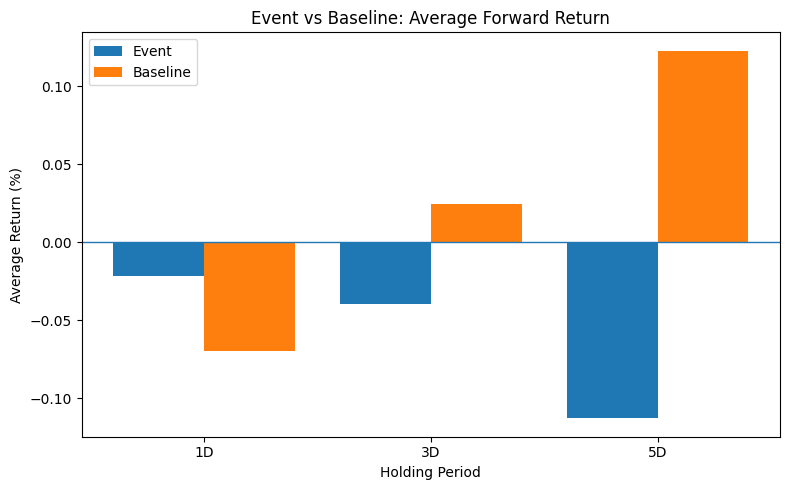

In [117]:
import matplotlib.pyplot as plt

periods = [1, 3, 5]

event_mean = [
    results_5d[f"Return_{d}D"].mean()
    for d in periods
]

baseline_mean = [
    baseline[f"Return_{d}D"].mean()
    for d in periods
]

x = range(len(periods))

plt.figure(figsize=(8, 5))

plt.bar(
    [i - 0.2 for i in x],
    event_mean,
    width=0.4,
    label="Event"
)

plt.bar(
    [i + 0.2 for i in x],
    baseline_mean,
    width=0.4,
    label="Baseline"
)

plt.axhline(0, linewidth=1)

plt.xticks(x, ["1D", "3D", "5D"])
plt.xlabel("Holding Period")
plt.ylabel("Average Return (%)")
plt.title("Event vs Baseline: Average Forward Return")
plt.legend()

plt.tight_layout()
plt.show()

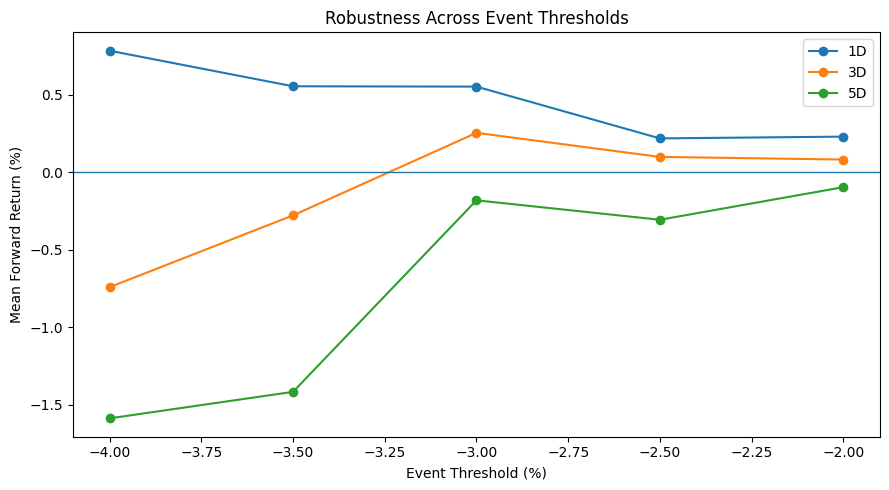

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    robustness["Threshold"],
    robustness["Mean_1D"],
    marker="o",
    label="1D"
)

plt.plot(
    robustness["Threshold"],
    robustness["Mean_3D"],
    marker="o",
    label="3D"
)

plt.plot(
    robustness["Threshold"],
    robustness["Mean_5D"],
    marker="o",
    label="5D"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Event Threshold (%)")
plt.ylabel("Mean Forward Return (%)")
plt.title("Robustness Across Event Thresholds")
plt.legend()

plt.tight_layout()
plt.show()

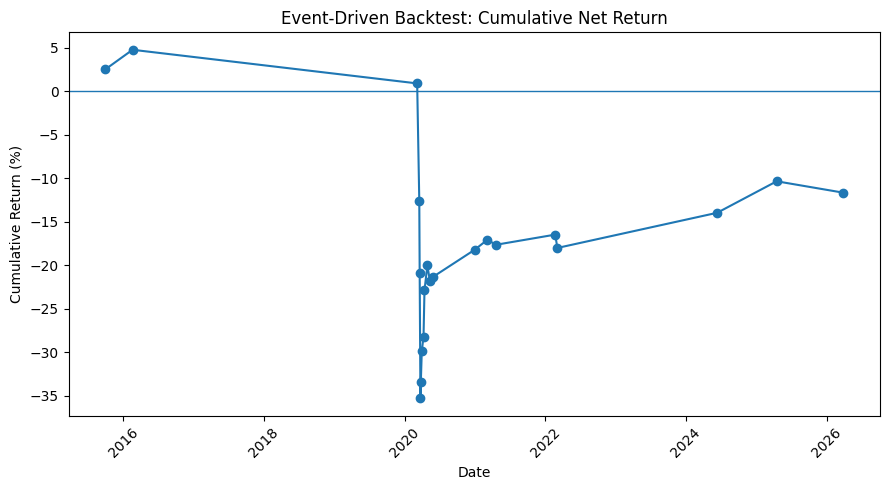

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    backtest["Exit_Date"],
    backtest["Cumulative_Return"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.title("Event-Driven Backtest: Cumulative Net Return")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
## Conclusion

This study tested whether a significant one-day decline in the NIFTY is followed by a recovery over the next few trading days. A decline of **3% or more** was defined as an event, with entry at the **next trading day's Open** and exits after **1, 3, and 5 trading days**. The analysis covered NIFTY observations from **22 September 2015 to 18 September 2026**, producing **41 qualifying events**.

The results provide **limited evidence of a short-term rebound, but do not provide statistically significant evidence of a persistent recovery effect**. The mean event returns were **-0.022% after 1 day, -0.040% after 3 days, and -0.113% after 5 days**. Compared with the baseline, the 1-day event return was **0.048 percentage points higher**, while the 3-day and 5-day differences were **-0.064 and -0.236 percentage points**, respectively.

Statistical tests did not reject the null hypothesis at the 5% significance level. The one-sided p-values were **0.431, 0.553, and 0.635** for the 1-, 3-, and 5-day horizons. Bootstrap confidence intervals for the event-minus-baseline differences also included zero for all three horizons. Therefore, the observed differences cannot be distinguished reliably from sampling variation.

Robustness analysis showed that the **1-day return remained positive across thresholds from -2% to -4%**, suggesting some descriptive evidence of a short-term bounce. However, the 3-day effect became inconsistent at stricter thresholds, while the 5-day mean return remained negative across all tested thresholds. This indicates that the apparent short-term rebound does not translate into a stable multi-day recovery pattern.

The out-of-sample period produced only **two qualifying events** after the July 2024 split. Although their observed returns were positive on average, the sample is too small to provide meaningful evidence of persistence. This is an important limitation rather than evidence confirming the hypothesis.

Transaction costs and slippage further weakened the result. Under an assumed **0.20% round-trip impact**, average event returns became **-0.222%, -0.240%, and -0.313%** for the 1-, 3-, and 5-day horizons. A simple 5-day event-driven backtest generated **21 trades**, an average net return of **-0.381% per trade**, and **-11.66% cumulative return** under the stated assumptions.

Overall, the analysis **does not support the hypothesis as a statistically reliable or economically profitable trading strategy** over the tested sample. The evidence is more consistent with a possible short-lived bounce immediately after large declines rather than a persistent 3- to 5-day recovery. The main limitations are the relatively small number of events, particularly in the out-of-sample period, possible dependence among closely timed events, market-regime differences, and sensitivity to transaction costs and parameter choices.
